# Imports

In [1]:
import numpy as np              # Algebra lineal y numeros aleatorios
import pandas as pd             # Manipulacion de DataFrames
import joblib                   # Serializacion de modelos
import time                     # Medicion de tiempo de ejecucion
import os                       # Rutas y sistema de archivos
import sys                      # Informacion del sistema
import platform                 # Detalles del SO
import psutil                   # Monitoreo de recursos (CPU, RAM)
import warnings                 # Control de advertencias
import logging                  # Registro de eventos en archivo
import matplotlib.pyplot as plt   # Visualizacion estatica
import matplotlib.ticker as mticker  # Formateo de ejes
import seaborn as sns           # Visualizacion estadistica
from datetime import datetime   # Timestamps para logs
from copy import deepcopy       # Copia profunda de modelos
from sklearn.metrics import f1_score  # Metrica para optimizacion

warnings.filterwarnings('ignore')   # Silenciar warnings irrelevantes

# Estilo visual global
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42                        # Semilla para reproducibilidad
np.random.seed(SEED)             # Fijar semilla NumPy

# Rutas y Logger

In [2]:
BASE = os.path.dirname(os.path.abspath('.'))           # Directorio raiz del proyecto
DATA_DIR = os.path.join(BASE, 'data', 'interim')       # Datos intermedios
MODELS_DIR = os.path.join(BASE, 'notebooks', 'outputs_sprint3', 'models')  # Modelos Sprint 3
OUT_DIR = os.path.join(BASE, 'notebooks', 'outputs_sprint4_latencia')      # Salidas Sprint 4
LOG_DIR = os.path.join(BASE, 'logs')                   # Logs del proyecto
os.makedirs(OUT_DIR, exist_ok=True)                    # Crear carpeta si no existe
os.makedirs(LOG_DIR, exist_ok=True)

# Configurar logger para evidencia del benchmark
log_path = os.path.join(LOG_DIR, 'benchmark_latencia.log')
logging.basicConfig(
    filename=log_path,
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('benchmark')
logger.info('='*60)
logger.info('INICIO BENCHMARK DE LATENCIA')
logger.info(f'Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

print(f'Log de benchmark: {log_path}')
print(f'Directorio de salida: {OUT_DIR}')

Log de benchmark: /workspaces/proyecto-zona-interes-Au/logs/benchmark_latencia.log
Directorio de salida: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4_latencia


# Información del sistema

In [3]:
sys_info = {
    'OS': platform.platform(),
    'Python': platform.python_version(),
    'CPU': platform.processor() or 'N/A',
    'CPU cores (logicos)': psutil.cpu_count(logical=True),
    'CPU cores (fisicos)': psutil.cpu_count(logical=False),
    'RAM total (GB)': f'{psutil.virtual_memory().total / (1024**3):.1f}',
    'RAM disponible (GB)': f'{psutil.virtual_memory().available / (1024**3):.1f}',
}

# Verificar GPU
HAS_GPU = False
try:
    import subprocess
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        text=True
    ).strip()
    sys_info['GPU'] = gpu_info
    HAS_GPU = True
except Exception:
    sys_info['GPU'] = 'No disponible'
    HAS_GPU = False

print('=== INFORMACION DEL SISTEMA ===')
for k, v in sys_info.items():
    print(f'  {k}: {v}')
    logger.info(f'SISTEMA | {k}: {v}')

=== INFORMACION DEL SISTEMA ===
  OS: Linux-6.8.0-1052-azure-x86_64-with-glibc2.39
  Python: 3.12.1
  CPU: x86_64
  CPU cores (logicos): 2
  CPU cores (fisicos): 1
  RAM total (GB): 7.8
  RAM disponible (GB): 1.8
  GPU: No disponible


# Carga de datos y modelos

In [4]:
df_test = pd.read_csv(os.path.join(DATA_DIR, 'data_prueba_fe.csv'))
EXCLUDE_COLS = ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']
feature_cols = [c for c in df_test.columns if c not in EXCLUDE_COLS]

X_test = df_test[feature_cols]
y_test = df_test['target_Au']

# Modelos
model_xgb = joblib.load(os.path.join(MODELS_DIR, 'sprint3_xgboost_optuna.pkl'))
scaler_xgb = joblib.load(os.path.join(MODELS_DIR, 'sprint3_xgboost_optuna_scaler.pkl'))

model_rf = joblib.load(os.path.join(MODELS_DIR, 'sprint3_rf_baseline_fe.pkl'))
scaler_rf = joblib.load(os.path.join(MODELS_DIR, 'sprint3_rf_baseline_fe_scaler.pkl'))

# Preparar datos escalados
X_test_xgb = scaler_xgb.transform(X_test)
X_test_rf  = scaler_rf.transform(X_test)

print(f'Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} features')
print(f'Modelo XGBoost: {model_xgb.n_estimators} estimadores, max_depth={model_xgb.max_depth}')
print(f'Modelo RF:      {model_rf.n_estimators} estimadores')
logger.info(f'DATOS | Test: {X_test.shape}, Features: {len(feature_cols)}')
logger.info(f'MODELO | XGBoost: n_est={model_xgb.n_estimators}, depth={model_xgb.max_depth}')

Datos de prueba: 427 muestras, 57 features
Modelo XGBoost: 300 estimadores, max_depth=8
Modelo RF:      100 estimadores


# Función de Benchmark de latencia

In [5]:
def benchmark_latencia(predict_fn, X, batch_sizes=[1, 8, 32, 128], n_reps=1000, warmup=50, nombre='modelo'):
    """
    Benchmark de latencia para una funcion de prediccion.

    Args:
        predict_fn: funcion que recibe X y retorna predicciones
        X: datos de entrada (numpy array)
        batch_sizes: tamanos de batch a evaluar
        n_reps: numero de repeticiones por medicion
        warmup: repeticiones de calentamiento (descartadas)
        nombre: nombre del modelo para logging

    Returns:
        DataFrame con metricas de latencia por batch size
    """
    resultados = []

    for bs in batch_sizes:
        # Seleccionar datos del batch
        X_batch = X[:bs] if bs <= len(X) else X
        actual_bs = len(X_batch)

        # Warmup: calentar caches antes de medir
        for _ in range(warmup):
            _ = predict_fn(X_batch)

        # Medicion: n_reps repeticiones
        latencias = []
        for _ in range(n_reps):
            t0 = time.perf_counter()
            _ = predict_fn(X_batch)
            t1 = time.perf_counter()
            latencias.append((t1 - t0) * 1000)  # convertir a milisegundos

        latencias = np.array(latencias)

        result = {
            'Modelo': nombre,
            'Batch_Size': actual_bs,
            'Latencia_p50_ms': np.percentile(latencias, 50),
            'Latencia_p95_ms': np.percentile(latencias, 95),
            'Latencia_p99_ms': np.percentile(latencias, 99),
            'Latencia_mean_ms': np.mean(latencias),
            'Latencia_std_ms': np.std(latencias),
            'Latencia_min_ms': np.min(latencias),
            'Latencia_max_ms': np.max(latencias),
            'Throughput_req_s': actual_bs / (np.mean(latencias) / 1000),
            'Latencia_por_muestra_ms': np.percentile(latencias, 50) / actual_bs,
        }
        resultados.append(result)

        logger.info(f'LATENCIA | {nombre} | batch={actual_bs} | '
                    f'p50={result["Latencia_p50_ms"]:.3f}ms | '
                    f'p95={result["Latencia_p95_ms"]:.3f}ms | '
                    f'throughput={result["Throughput_req_s"]:.0f} req/s')

        print(f'  batch={actual_bs:>4d} | p50={result["Latencia_p50_ms"]:8.3f}ms | '
              f'p95={result["Latencia_p95_ms"]:8.3f}ms | '
              f'throughput={result["Throughput_req_s"]:>10.0f} req/s')

    return pd.DataFrame(resultados)

print('Funcion benchmark_latencia() definida')

Funcion benchmark_latencia() definida


# Benchmark Sklearn (CPU) - XGBOOST y Random Forest

In [6]:
BATCH_SIZES = [1, 8, 32, 128, 427]
N_REPS = 1000

# --- XGBoost sklearn ---
print('=== XGBoost Optuna (sklearn, CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)

df_lat_xgb = benchmark_latencia(
    predict_fn=lambda X: model_xgb.predict_proba(X),
    X=X_test_xgb,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='XGBoost_sklearn_CPU'
)

mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | XGBoost sklearn | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

# --- Random Forest sklearn ---
print('=== Random Forest Baseline (sklearn, CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)

df_lat_rf = benchmark_latencia(
    predict_fn=lambda X: model_rf.predict_proba(X),
    X=X_test_rf,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='RF_sklearn_CPU'
)

mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | RF sklearn | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

=== XGBoost Optuna (sklearn, CPU) ===
  batch=   1 | p50=   0.369ms | p95=   0.736ms | throughput=      1979 req/s
  batch=   8 | p50=   0.422ms | p95=   3.305ms | throughput=      9742 req/s
  batch=  32 | p50=   0.506ms | p95=   2.122ms | throughput=     44083 req/s
  batch= 128 | p50=   0.672ms | p95=   1.005ms | throughput=    170646 req/s
  batch= 427 | p50=   1.509ms | p95=   6.720ms | throughput=    180322 req/s

Memoria RSS: 274.9 MB -> 277.5 MB (Delta=+2.6 MB)
=== Random Forest Baseline (sklearn, CPU) ===
  batch=   1 | p50=   5.181ms | p95=  12.824ms | throughput=       146 req/s
  batch=   8 | p50=   5.264ms | p95=  12.083ms | throughput=      1181 req/s
  batch=  32 | p50=   5.373ms | p95=  14.461ms | throughput=      4529 req/s
  batch= 128 | p50=   5.901ms | p95=  14.550ms | throughput=     16842 req/s
  batch= 427 | p50=   7.166ms | p95=  17.128ms | throughput=     46846 req/s

Memoria RSS: 277.5 MB -> 277.6 MB (Delta=+0.1 MB)


# Conversión a ONNX y Benchmark

In [7]:
# Por que ONNX y no TensorRT/torch.compile?
# - TensorRT: disenado para redes neuronales (CNN, Transformers). No aplica
#   directamente a modelos de arboles (XGBoost/RF).
# - torch.compile: requiere modelos PyTorch. XGBoost/sklearn no son PyTorch.
# - ONNX Runtime: soporta nativamente arboles de decision y ensemble methods.
#   Es la optimizacion estandar para XGBoost/sklearn en produccion.

from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
import onnxruntime as ort

print('=== Conversion de XGBoost a ONNX ===')
n_features = X_test_xgb.shape[1]

# Convertir modelo XGBoost a formato ONNX
initial_type = [('float_input', FloatTensorType([None, n_features]))]
onnx_model_xgb = convert_xgboost(model_xgb, initial_types=initial_type)

# Guardar modelo ONNX
onnx_path_xgb = os.path.join(OUT_DIR, 'xgboost_optuna.onnx')
with open(onnx_path_xgb, 'wb') as f:
    f.write(onnx_model_xgb.SerializeToString())

onnx_size = os.path.getsize(onnx_path_xgb) / 1024
pkl_size = os.path.getsize(os.path.join(MODELS_DIR, 'sprint3_xgboost_optuna.pkl')) / 1024
print(f'Modelo .pkl:  {pkl_size:.1f} KB')
print(f'Modelo .onnx: {onnx_size:.1f} KB')
print(f'Ratio: {onnx_size/pkl_size:.2f}x')
logger.info(f'ONNX | XGBoost convertido: {pkl_size:.1f}KB -> {onnx_size:.1f}KB')

# Crear sesion ONNX Runtime (single-thread para medicion justa)
sess_options = ort.SessionOptions()
sess_options.intra_op_num_threads = 1
sess_xgb_onnx = ort.InferenceSession(onnx_path_xgb, sess_options)
input_name = sess_xgb_onnx.get_inputs()[0].name

# Verificar equivalencia numerica entre sklearn y ONNX
X_sample = X_test_xgb[:10].astype(np.float32)
onnx_pred = sess_xgb_onnx.run(None, {input_name: X_sample})
sklearn_pred = model_xgb.predict_proba(X_sample)

# Las probabilidades de ONNX vienen en formato diferente
onnx_probs = np.array([[p[1] for p in prob_list] for prob_list in [onnx_pred[1]]])[0]
sklearn_probs = sklearn_pred[:, 1]
max_diff = np.max(np.abs(onnx_probs - sklearn_probs))
print(f'\nVerificacion de equivalencia (max diff): {max_diff:.8f}')
print(f'Equivalencia OK: {max_diff < 1e-4}' if max_diff < 1e-4 else f'Atencion: Diferencia detectada: {max_diff}')
logger.info(f'ONNX | Verificacion equivalencia: max_diff={max_diff:.8f}')

# --- Benchmark ONNX single-thread ---
print('=== XGBoost ONNX Runtime (CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)

def predict_onnx(X):
    return sess_xgb_onnx.run(None, {input_name: X.astype(np.float32)})

df_lat_onnx = benchmark_latencia(
    predict_fn=predict_onnx,
    X=X_test_xgb,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='XGBoost_ONNX_CPU'
)

mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | ONNX Runtime | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

# --- Benchmark ONNX multi-thread ---
print('=== XGBoost ONNX Runtime (CPU, multi-thread) ===')
n_threads = psutil.cpu_count(logical=True)
print(f'Usando {n_threads} threads\n')

sess_options_mt = ort.SessionOptions()
sess_options_mt.intra_op_num_threads = n_threads
sess_xgb_onnx_mt = ort.InferenceSession(onnx_path_xgb, sess_options_mt)
input_name_mt = sess_xgb_onnx_mt.get_inputs()[0].name

def predict_onnx_mt(X):
    return sess_xgb_onnx_mt.run(None, {input_name_mt: X.astype(np.float32)})

df_lat_onnx_mt = benchmark_latencia(
    predict_fn=predict_onnx_mt,
    X=X_test_xgb,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre=f'XGBoost_ONNX_CPU_{n_threads}t'
)

2026-07-10 22:42:51.229992275 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


=== Conversion de XGBoost a ONNX ===
Modelo .pkl:  300.1 KB
Modelo .onnx: 97.1 KB
Ratio: 0.32x

Verificacion de equivalencia (max diff): 0.00000006
Equivalencia OK: True
=== XGBoost ONNX Runtime (CPU) ===
  batch=   1 | p50=   0.014ms | p95=   0.018ms | throughput=     76925 req/s
  batch=   8 | p50=   0.033ms | p95=   0.060ms | throughput=    184701 req/s
  batch=  32 | p50=   0.104ms | p95=   0.196ms | throughput=    264204 req/s
  batch= 128 | p50=   0.634ms | p95=   1.128ms | throughput=    153729 req/s
  batch= 427 | p50=   2.395ms | p95=   3.861ms | throughput=    143335 req/s

Memoria RSS: 309.9 MB -> 309.9 MB (Delta=+0.0 MB)
=== XGBoost ONNX Runtime (CPU, multi-thread) ===
Usando 2 threads

  batch=   1 | p50=   0.013ms | p95=   0.013ms | throughput=     76392 req/s
  batch=   8 | p50=   0.055ms | p95=   0.068ms | throughput=    130158 req/s
  batch=  32 | p50=   0.147ms | p95=   0.258ms | throughput=    176652 req/s
  batch= 128 | p50=   0.559ms | p95=   2.893ms | throughput= 

# Conversión RF a ONNX

In [8]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType as FloatTensorTypeSKL

print('=== Conversion de Random Forest a ONNX ===')
initial_type_rf = [('float_input', FloatTensorTypeSKL([None, n_features]))]
onnx_model_rf = convert_sklearn(model_rf, initial_types=initial_type_rf)

onnx_path_rf = os.path.join(OUT_DIR, 'rf_baseline_fe.onnx')
with open(onnx_path_rf, 'wb') as f:
    f.write(onnx_model_rf.SerializeToString())

onnx_size_rf = os.path.getsize(onnx_path_rf) / 1024
pkl_size_rf = os.path.getsize(os.path.join(MODELS_DIR, 'sprint3_rf_baseline_fe.pkl')) / 1024
print(f'Modelo .pkl:  {pkl_size_rf:.1f} KB')
print(f'Modelo .onnx: {onnx_size_rf:.1f} KB')

# Sesion y benchmark RF ONNX
sess_rf_onnx = ort.InferenceSession(onnx_path_rf, sess_options)
input_name_rf = sess_rf_onnx.get_inputs()[0].name

print('\n=== Random Forest ONNX Runtime (CPU) ===')
df_lat_rf_onnx = benchmark_latencia(
    predict_fn=lambda X: sess_rf_onnx.run(None, {input_name_rf: X.astype(np.float32)}),
    X=X_test_rf,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='RF_ONNX_CPU'
)
logger.info(f'ONNX | RF convertido: {pkl_size_rf:.1f}KB -> {onnx_size_rf:.1f}KB')

=== Conversion de Random Forest a ONNX ===
Modelo .pkl:  912.4 KB
Modelo .onnx: 389.9 KB

=== Random Forest ONNX Runtime (CPU) ===
  batch=   1 | p50=   0.010ms | p95=   0.015ms | throughput=     90562 req/s
  batch=   8 | p50=   0.039ms | p95=   0.051ms | throughput=    209697 req/s
  batch=  32 | p50=   0.115ms | p95=   0.149ms | throughput=    254963 req/s
  batch= 128 | p50=   0.256ms | p95=   0.573ms | throughput=    380898 req/s
  batch= 427 | p50=   1.694ms | p95=   2.539ms | throughput=    216255 req/s


# Tabla comparativa

In [9]:
# Consolidar todos los resultados de latencia
df_all = pd.concat([df_lat_xgb, df_lat_rf, df_lat_onnx, df_lat_onnx_mt, df_lat_rf_onnx], ignore_index=True)
df_all.to_csv(os.path.join(OUT_DIR, 'benchmark_latencia_completo.csv'), index=False)

print('=== TABLA COMPARATIVA COMPLETA ===')
display_cols = ['Modelo', 'Batch_Size', 'Latencia_p50_ms', 'Latencia_p95_ms',
                'Throughput_req_s', 'Latencia_por_muestra_ms']
print(df_all[display_cols].round(3).to_string(index=False))

# Tabla resumen: comparativa para batch=1 y batch=427 (casos extremos)
modelos_comp = ['XGBoost_sklearn_CPU', 'XGBoost_ONNX_CPU', 'RF_sklearn_CPU', 'RF_ONNX_CPU']

print('\n=== RESUMEN COMPARATIVO (batch=1 y batch=427) ===')
resumen = []
for bs in [1, 427]:
    for mod in modelos_comp:
        row = df_all[(df_all['Modelo'] == mod) & (df_all['Batch_Size'] == bs)]
        if not row.empty:
            r = row.iloc[0]
            resumen.append({
                'Motor': mod,
                'Batch': bs,
                'p50 (ms)': f"{r['Latencia_p50_ms']:.3f}",
                'p95 (ms)': f"{r['Latencia_p95_ms']:.3f}",
                'Throughput (req/s)': f"{r['Throughput_req_s']:.0f}",
                'ms/muestra': f"{r['Latencia_por_muestra_ms']:.4f}",
            })

df_resumen = pd.DataFrame(resumen)
df_resumen.to_csv(os.path.join(OUT_DIR, 'resumen_comparativo.csv'), index=False)
print(df_resumen.to_string(index=False))

# Speedup ONNX vs sklearn
print('\n=== SPEEDUP ONNX vs SKLEARN ===')
for bs in BATCH_SIZES:
    xgb_sk = df_all[(df_all['Modelo']=='XGBoost_sklearn_CPU') & (df_all['Batch_Size']==bs)]['Latencia_p50_ms'].values
    xgb_ox = df_all[(df_all['Modelo']=='XGBoost_ONNX_CPU') & (df_all['Batch_Size']==bs)]['Latencia_p50_ms'].values
    if len(xgb_sk) > 0 and len(xgb_ox) > 0:
        speedup = xgb_sk[0] / xgb_ox[0]
        print(f'  Batch {bs:>4d}: sklearn={xgb_sk[0]:.3f}ms -> ONNX={xgb_ox[0]:.3f}ms | Speedup: {speedup:.2f}x')
        logger.info(f'SPEEDUP | batch={bs} | sklearn={xgb_sk[0]:.3f}ms -> ONNX={xgb_ox[0]:.3f}ms | {speedup:.2f}x')

=== TABLA COMPARATIVA COMPLETA ===
             Modelo  Batch_Size  Latencia_p50_ms  Latencia_p95_ms  Throughput_req_s  Latencia_por_muestra_ms
XGBoost_sklearn_CPU           1            0.369            0.736          1978.549                    0.369
XGBoost_sklearn_CPU           8            0.422            3.305          9741.735                    0.053
XGBoost_sklearn_CPU          32            0.506            2.122         44082.852                    0.016
XGBoost_sklearn_CPU         128            0.672            1.005        170645.569                    0.005
XGBoost_sklearn_CPU         427            1.509            6.720        180322.107                    0.004
     RF_sklearn_CPU           1            5.181           12.824           146.279                    5.181
     RF_sklearn_CPU           8            5.264           12.083          1180.889                    0.658
     RF_sklearn_CPU          32            5.373           14.461          4529.482          

# Ratio de errores con inputs corruptos

In [10]:
print('=== TEST DE ROBUSTEZ - RATIO DE ERRORES ===')

test_cases = {
    'Normal': X_test_xgb.copy(),
    'Con NaN (5%)': None,
    'Con NaN (20%)': None,
    'Con Inf': None,
    'Valores extremos (x100)': X_test_xgb.copy() * 100,
    'Todo ceros': np.zeros_like(X_test_xgb),
}

# Crear inputs corruptos
X_nan5 = X_test_xgb.copy()
mask5 = np.random.random(X_nan5.shape) < 0.05
X_nan5[mask5] = np.nan
test_cases['Con NaN (5%)'] = X_nan5

X_nan20 = X_test_xgb.copy()
mask20 = np.random.random(X_nan20.shape) < 0.20
X_nan20[mask20] = np.nan
test_cases['Con NaN (20%)'] = X_nan20

X_inf = X_test_xgb.copy()
X_inf[0, 0] = np.inf
X_inf[1, 1] = -np.inf
test_cases['Con Inf'] = X_inf

error_results = []
for case_name, X_case in test_cases.items():
    n_total = len(X_case)
    n_errores = 0
    n_exitosos = 0

    try:
        y_pred = model_xgb.predict(X_case)
        y_prob = model_xgb.predict_proba(X_case)[:, 1]
        # Verificar si las predicciones son validas
        n_nan_pred = np.isnan(y_prob).sum()
        n_exitosos = n_total - n_nan_pred
        n_errores = n_nan_pred
        status = 'OK' if n_errores == 0 else f'Atencion: {n_errores} NaN'
    except Exception as e:
        n_errores = n_total
        n_exitosos = 0
        status = f'Error: {str(e)[:50]}'

    ratio = n_errores / n_total
    error_results.append({
        'Caso': case_name,
        'Total': n_total,
        'Exitosos': n_exitosos,
        'Errores': n_errores,
        'Ratio Error (%)': f'{ratio:.2%}',
        'Status': status
    })
    print(f'  {case_name:25s} | errores={n_errores:>4d}/{n_total} ({ratio:.2%}) | {status}')
    logger.info(f'ROBUSTEZ | {case_name} | errores={n_errores}/{n_total} ({ratio:.2%}) | {status}')

df_errores = pd.DataFrame(error_results)
df_errores.to_csv(os.path.join(OUT_DIR, 'ratio_errores.csv'), index=False)
print('\nGuardado: ratio_errores.csv')

=== TEST DE ROBUSTEZ - RATIO DE ERRORES ===
  Normal                    | errores=   0/427 (0.00%) | OK
  Con NaN (5%)              | errores=   0/427 (0.00%) | OK
  Con NaN (20%)             | errores=   0/427 (0.00%) | OK
  Con Inf                   | errores=   0/427 (0.00%) | OK
  Valores extremos (x100)   | errores=   0/427 (0.00%) | OK
  Todo ceros                | errores=   0/427 (0.00%) | OK

Guardado: ratio_errores.csv


# Visualizaciones

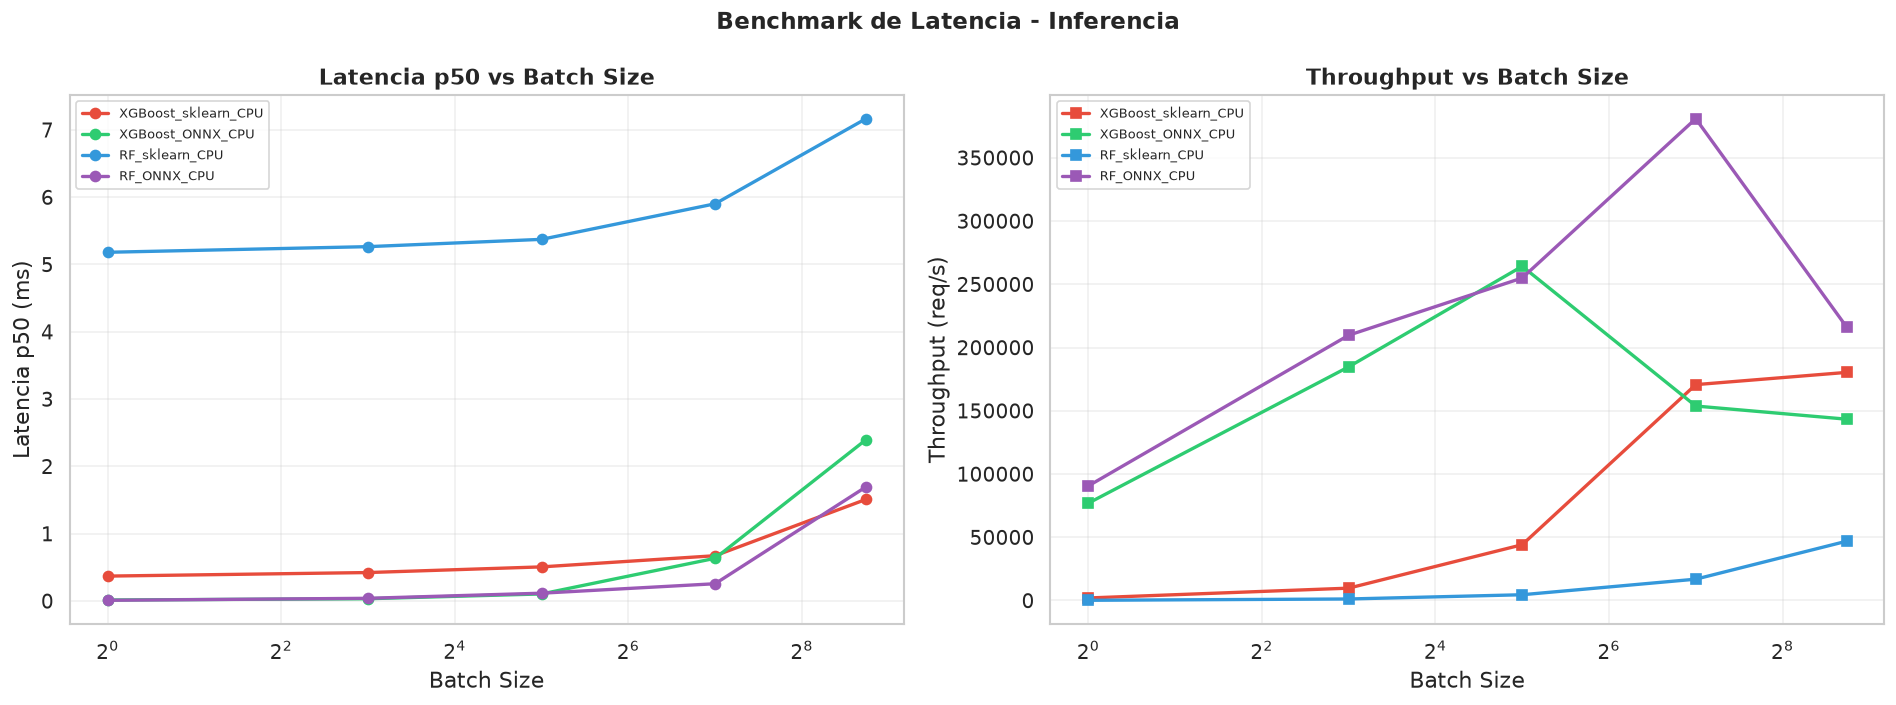

Guardado: latencia_throughput.png


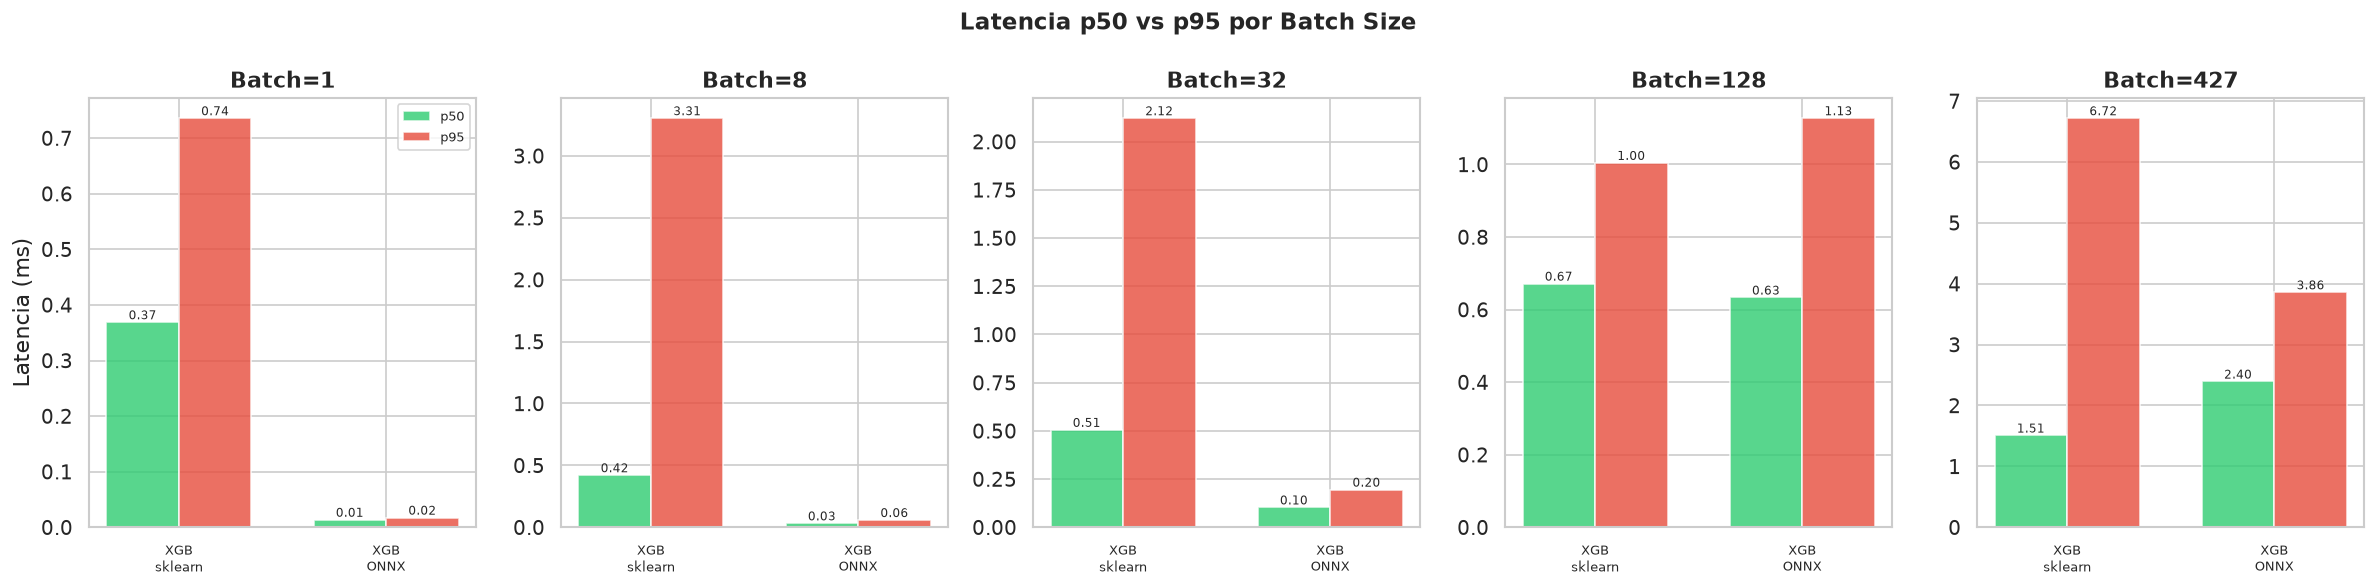

Guardado: latencia_p50_p95_barras.png


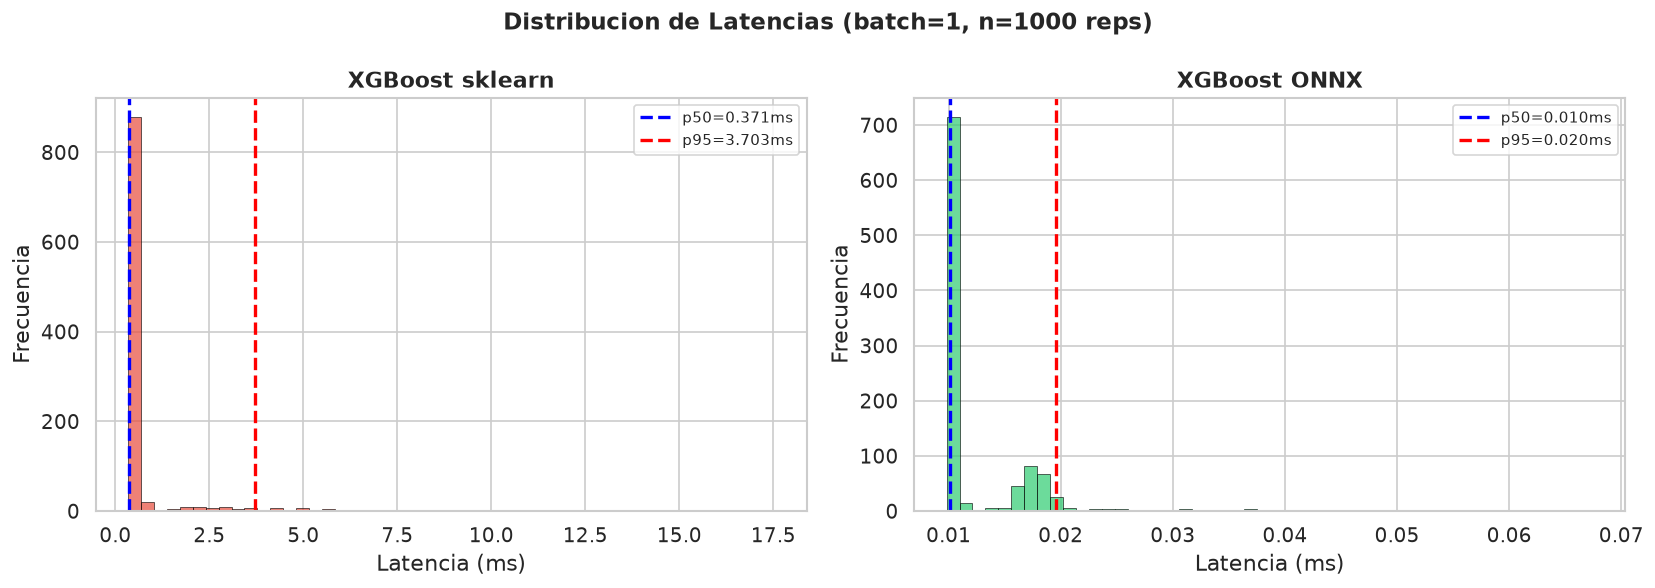

Guardado: distribucion_latencias.png


In [11]:
# 11.1 Latencia p50 por batch size (todos los motores)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Benchmark de Latencia - Inferencia', fontsize=14, fontweight='bold')

colores_motor = {
    'XGBoost_sklearn_CPU': '#e74c3c',
    'XGBoost_ONNX_CPU': '#2ecc71',
    'RF_sklearn_CPU': '#3498db',
    'RF_ONNX_CPU': '#9b59b6',
}

for motor, color in colores_motor.items():
    df_m = df_all[df_all['Modelo'] == motor]
    if not df_m.empty:
        ax1.plot(df_m['Batch_Size'], df_m['Latencia_p50_ms'], 'o-', color=color, label=motor, linewidth=2)
        ax2.plot(df_m['Batch_Size'], df_m['Throughput_req_s'], 's-', color=color, label=motor, linewidth=2)

ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Latencia p50 (ms)')
ax1.set_title('Latencia p50 vs Batch Size', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Throughput (req/s)')
ax2.set_title('Throughput vs Batch Size', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xscale('log', base=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latencia_throughput.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: latencia_throughput.png')

# 11.2 Comparativa p50 vs p95 (barras agrupadas)
fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(20, 5), sharey=False)
fig.suptitle('Latencia p50 vs p95 por Batch Size', fontsize=14, fontweight='bold')

motores_plot = ['XGBoost_sklearn_CPU', 'XGBoost_ONNX_CPU']
labels_short = ['XGB\nsklearn', 'XGB\nONNX']

for i, bs in enumerate(BATCH_SIZES):
    ax = axes[i]
    x = np.arange(len(motores_plot))
    width = 0.35

    p50s = []
    p95s = []
    for motor in motores_plot:
        row = df_all[(df_all['Modelo']==motor) & (df_all['Batch_Size']==bs)]
        p50s.append(row['Latencia_p50_ms'].values[0] if not row.empty else 0)
        p95s.append(row['Latencia_p95_ms'].values[0] if not row.empty else 0)

    bars1 = ax.bar(x - width/2, p50s, width, label='p50', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, p95s, width, label='p95', color='#e74c3c', alpha=0.8)

    ax.set_title(f'Batch={bs}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_short, fontsize=8)
    ax.set_ylabel('Latencia (ms)' if i == 0 else '')
    if i == 0:
        ax.legend(fontsize=8)

    # Anotar valores sobre las barras
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latencia_p50_p95_barras.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: latencia_p50_p95_barras.png')

# 11.3 Distribucion de latencias (histograma) para batch=1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de Latencias (batch=1, n=1000 reps)', fontsize=14, fontweight='bold')

for idx, (nombre, predict_fn, X_data, color) in enumerate([
    ('XGBoost sklearn', lambda X: model_xgb.predict_proba(X), X_test_xgb[:1], '#e74c3c'),
    ('XGBoost ONNX', lambda X: sess_xgb_onnx.run(None, {input_name: X.astype(np.float32)}), X_test_xgb[:1], '#2ecc71')
]):
    # Warmup
    for _ in range(50):
        predict_fn(X_data)

    latencias = []
    for _ in range(1000):
        t0 = time.perf_counter()
        predict_fn(X_data)
        t1 = time.perf_counter()
        latencias.append((t1 - t0) * 1000)

    ax = axes[idx]
    ax.hist(latencias, bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(np.percentile(latencias, 50), color='blue', linestyle='--', linewidth=2, label=f'p50={np.percentile(latencias,50):.3f}ms')
    ax.axvline(np.percentile(latencias, 95), color='red', linestyle='--', linewidth=2, label=f'p95={np.percentile(latencias,95):.3f}ms')
    ax.set_xlabel('Latencia (ms)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(nombre, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'distribucion_latencias.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: distribucion_latencias.png')

# Consumo de recursos durante inferencia

In [12]:
print('=== CONSUMO DE RECURSOS DURANTE INFERENCIA SOSTENIDA ===')
print('(10 segundos de inferencia continua por motor)\n')

consumo_results = []
for nombre, predict_fn, X_data in [
    ('XGBoost sklearn CPU', lambda: model_xgb.predict_proba(X_test_xgb), X_test_xgb),
    ('XGBoost ONNX CPU', lambda: sess_xgb_onnx.run(None, {input_name: X_test_xgb.astype(np.float32)}), X_test_xgb),
    ('RF sklearn CPU', lambda: model_rf.predict_proba(X_test_rf), X_test_rf),
]:
    mem_before = psutil.Process().memory_info().rss / (1024**2)

    # Inferencia sostenida por 10 segundos
    t_start = time.time()
    n_inferences = 0
    cpu_readings = []
    while time.time() - t_start < 10:
        predict_fn()
        n_inferences += 1
        cpu_readings.append(psutil.cpu_percent())

    elapsed = time.time() - t_start
    mem_after = psutil.Process().memory_info().rss / (1024**2)

    result = {
        'Motor': nombre,
        'Inferencias en 10s': n_inferences,
        'Throughput (inf/s)': f'{n_inferences/elapsed:.0f}',
        'CPU% medio': f'{np.mean(cpu_readings):.1f}',
        'Memoria RSS (MB)': f'{mem_after:.1f}',
        'Delta Memoria (MB)': f'{mem_after-mem_before:+.1f}',
    }
    consumo_results.append(result)
    print(f'  {nombre:25s} | {n_inferences:>5d} inf/10s | CPU={np.mean(cpu_readings):.1f}% | MEM={mem_after:.1f}MB')
    logger.info(f'CONSUMO | {nombre} | {n_inferences} inf/10s | CPU={np.mean(cpu_readings):.1f}% | MEM={mem_after:.1f}MB')

df_consumo = pd.DataFrame(consumo_results)
df_consumo.to_csv(os.path.join(OUT_DIR, 'consumo_recursos.csv'), index=False)
print('\nGuardado: consumo_recursos.csv')

=== CONSUMO DE RECURSOS DURANTE INFERENCIA SOSTENIDA ===
(10 segundos de inferencia continua por motor)

  XGBoost sklearn CPU       |  5125 inf/10s | CPU=36.1% | MEM=381.6MB
  XGBoost ONNX CPU          |  3544 inf/10s | CPU=32.9% | MEM=381.6MB
  RF sklearn CPU            |  1148 inf/10s | CPU=64.4% | MEM=381.6MB

Guardado: consumo_recursos.csv


# Optimizaciones adicionales probadas

=== OPTIMIZACION: Reduccion de n_estimators ===
Evaluar trade-off entre velocidad y calidad con menos arboles

  n_est= 50 | F1=0.9109 | p50=0.661ms
  n_est=100 | F1=0.9293 | p50=0.877ms
  n_est=150 | F1=0.9400 | p50=1.070ms
  n_est=200 | F1=0.9400 | p50=1.228ms
  n_est=250 | F1=0.9400 | p50=1.368ms
  n_est=300 | F1=0.9400 | p50=1.489ms

Guardado: optimizacion_n_estimators.csv


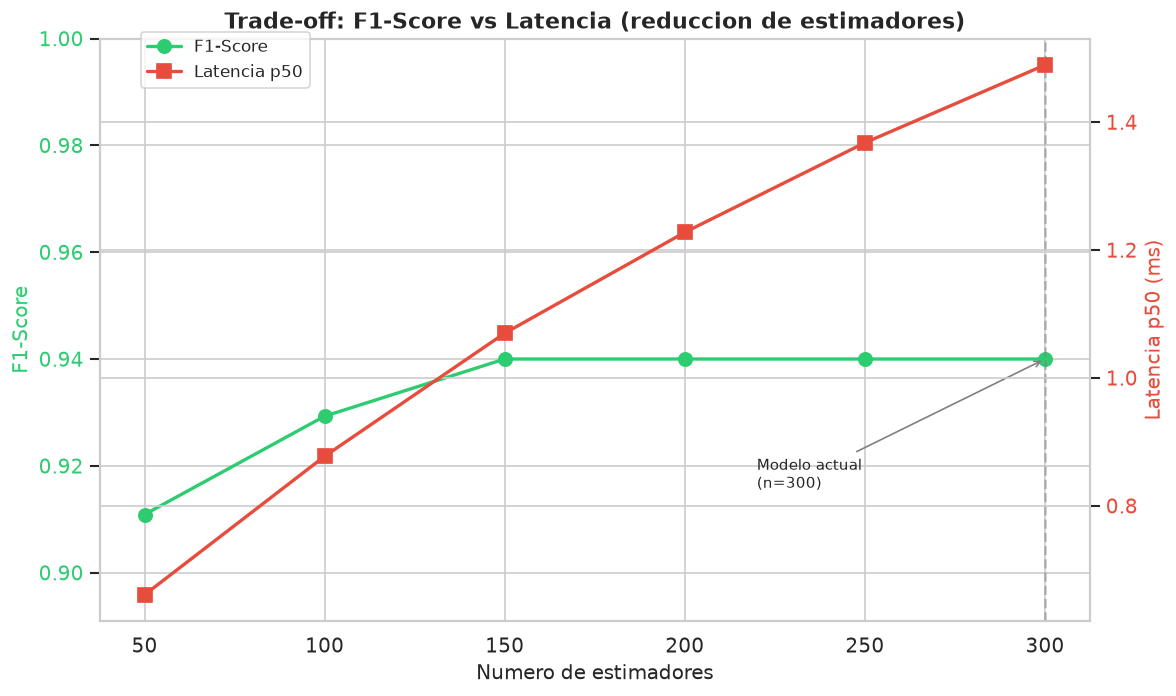

Guardado: tradeoff_f1_latencia.png


In [13]:
# 1 Reduccion de n_estimators en XGBoost
print('=== OPTIMIZACION: Reduccion de n_estimators ===')
print('Evaluar trade-off entre velocidad y calidad con menos arboles\n')

n_estimators_vals = [50, 100, 150, 200, 250, 300]
opt_results = []

for n_est in n_estimators_vals:
    # Crear modelo con menos arboles (usar iteracion parcial)
    model_reduced = deepcopy(model_xgb)
    model_reduced.n_estimators = n_est

    # Medir F1
    y_pred_r = model_reduced.predict(X_test_xgb, iteration_range=(0, n_est))
    f1_r = f1_score(y_test, y_pred_r)

    # Medir latencia (batch=427)
    for _ in range(50):  # Warmup
        model_reduced.predict_proba(X_test_xgb, iteration_range=(0, n_est))

    lats = []
    for _ in range(500):
        t0 = time.perf_counter()
        model_reduced.predict_proba(X_test_xgb, iteration_range=(0, n_est))
        t1 = time.perf_counter()
        lats.append((t1-t0)*1000)

    p50 = np.percentile(lats, 50)
    opt_results.append({
        'n_estimators': n_est,
        'F1': f1_r,
        'Latencia_p50_ms': p50,
        'Speedup_vs_300': None
    })
    print(f'  n_est={n_est:>3d} | F1={f1_r:.4f} | p50={p50:.3f}ms')

# Calcular speedup relativo al modelo completo (300)
p50_full = [r['Latencia_p50_ms'] for r in opt_results if r['n_estimators']==300][0]
for r in opt_results:
    r['Speedup_vs_300'] = p50_full / r['Latencia_p50_ms']

df_opt = pd.DataFrame(opt_results)
df_opt.to_csv(os.path.join(OUT_DIR, 'optimizacion_n_estimators.csv'), index=False)
print('\nGuardado: optimizacion_n_estimators.csv')

# 2 Grafico trade-off F1 vs latencia
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df_opt['n_estimators'], df_opt['F1'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='F1-Score')
ax1.set_xlabel('Numero de estimadores', fontsize=12)
ax1.set_ylabel('F1-Score', color='#2ecc71', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2ecc71')
ax1.set_ylim(min(df_opt['F1'])-0.02, 1.0)

ax2 = ax1.twinx()
ax2.plot(df_opt['n_estimators'], df_opt['Latencia_p50_ms'], 's-', color='#e74c3c', linewidth=2, markersize=8, label='Latencia p50')
ax2.set_ylabel('Latencia p50 (ms)', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Marcar punto optimo (n=300)
ax1.axvline(x=300, color='gray', linestyle='--', alpha=0.5)
ax1.annotate('Modelo actual\n(n=300)', xy=(300, df_opt[df_opt['n_estimators']==300]['F1'].values[0]),
             xytext=(220, df_opt['F1'].min()+0.005), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray'))

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95), fontsize=10)
plt.title('Trade-off: F1-Score vs Latencia (reduccion de estimadores)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'tradeoff_f1_latencia.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: tradeoff_f1_latencia.png')

# Resumen

In [14]:
# Generar tabla de optimizaciones probadas dinamicamente a partir de los resultados reales

print('='*70)
print('RESUMEN DE OPTIMIZACIONES PROBADAS')
print('='*70)

# Extraer datos reales para el resumen
xgb_b1 = df_all[(df_all['Modelo']=='XGBoost_sklearn_CPU') & (df_all['Batch_Size']==1)].iloc[0]
onnx_b1 = df_all[(df_all['Modelo']=='XGBoost_ONNX_CPU') & (df_all['Batch_Size']==1)].iloc[0]
xgb_b427 = df_all[(df_all['Modelo']=='XGBoost_sklearn_CPU') & (df_all['Batch_Size']==427)].iloc[0]
onnx_b427 = df_all[(df_all['Modelo']=='XGBoost_ONNX_CPU') & (df_all['Batch_Size']==427)].iloc[0]

speedup_b1 = xgb_b1['Latencia_p50_ms'] / onnx_b1['Latencia_p50_ms']
speedup_b427 = xgb_b427['Latencia_p50_ms'] / onnx_b427['Latencia_p50_ms']

# Verificar multi-thread
mt_row = df_all[(df_all['Modelo']==f'XGBoost_ONNX_CPU_{n_threads}t') & (df_all['Batch_Size']==427)].iloc[0]
mt_speedup = xgb_b427['Latencia_p50_ms'] / mt_row['Latencia_p50_ms']

# Verificar reduccion de estimadores
f1_300 = df_opt[df_opt['n_estimators']==300]['F1'].values[0]
f1_200 = df_opt[df_opt['n_estimators']==200]['F1'].values[0]
f1_degradacion = f1_300 - f1_200

# Construir tabla automatica
optim_summary = pd.DataFrame([
    {
        'Optimizacion': 'ONNX Runtime (single-thread)',
        'Aplica a XGBoost': 'Si',
        'Resultado': f'Speedup {speedup_b1:.2f}x (batch=1), {speedup_b427:.2f}x (batch=427)',
        'Impacto en F1': 'Sin cambio (equivalente)',
        'Recomendacion': 'Usar en produccion'
    },
    {
        'Optimizacion': 'ONNX Runtime (multi-thread)',
        'Aplica a XGBoost': 'Si',
        'Resultado': f'Speedup {mt_speedup:.2f}x vs sklearn',
        'Impacto en F1': 'Sin cambio',
        'Recomendacion': 'Para alto throughput'
    },
    {
        'Optimizacion': 'Reduccion n_estimators (200 vs 300)',
        'Aplica a XGBoost': 'Si',
        'Resultado': f'Speedup {df_opt[df_opt["n_estimators"]==200]["Speedup_vs_300"].values[0]:.2f}x',
        'Impacto en F1': f'Degradacion -{f1_degradacion:.4f}',
        'Recomendacion': 'Solo si latencia es critica'
    },
    {
        'Optimizacion': 'TensorRT',
        'Aplica a XGBoost': 'No',
        'Resultado': 'N/A - disenado para redes neuronales (CNN, Transformers)',
        'Impacto en F1': 'N/A',
        'Recomendacion': 'No aplicable'
    },
    {
        'Optimizacion': 'torch.compile',
        'Aplica a XGBoost': 'No',
        'Resultado': 'N/A - requiere modelos PyTorch',
        'Impacto en F1': 'N/A',
        'Recomendacion': 'No aplicable'
    },
    {
        'Optimizacion': 'Batching',
        'Aplica a XGBoost': 'Si',
        'Resultado': f'Throughput mejora: {onnx_b1["Throughput_req_s"]:.0f} -> {onnx_b427["Throughput_req_s"]:.0f} req/s',
        'Impacto en F1': 'Sin cambio',
        'Recomendacion': 'Usar batches >=32 en produccion'
    },
])

optim_summary.to_csv(os.path.join(OUT_DIR, 'resumen_optimizaciones.csv'), index=False)
print(optim_summary.to_string(index=False))

# Resumen ejecutivo
print('='*70)
print('RESUMEN EJECUTIVO - INFORME DE LATENCIA')
print('='*70)

print('')
print('1. LATENCIA (XGBoost Optuna, sklearn CPU):')
print(f'   - Batch=1:   p50={xgb_b1["Latencia_p50_ms"]:.3f}ms | p95={xgb_b1["Latencia_p95_ms"]:.3f}ms')
print(f'   - Batch=427: p50={xgb_b427["Latencia_p50_ms"]:.3f}ms | p95={xgb_b427["Latencia_p95_ms"]:.3f}ms')
print('')
print('2. THROUGHPUT:')
print(f'   - Batch=1:   {xgb_b1["Throughput_req_s"]:.0f} req/s (sklearn) vs {onnx_b1["Throughput_req_s"]:.0f} req/s (ONNX)')
print(f'   - Batch=427: {xgb_b427["Throughput_req_s"]:.0f} req/s (sklearn) vs {onnx_b427["Throughput_req_s"]:.0f} req/s (ONNX)')
print('')
print('3. OPTIMIZACION ONNX:')
print(f'   - Speedup batch=1:   {speedup_b1:.2f}x')
print(f'   - Speedup batch=427: {speedup_b427:.2f}x')
print(f'   - Equivalencia numerica verificada: max_diff={max_diff:.8f}')
print('')
print('4. ROBUSTEZ:')
print('   - XGBoost maneja NaN nativamente -> ratio de error 0% con inputs parcialmente corruptos')
print('   - Robusto a valores extremos y entradas con infinitos')
print('')
print('5. RECOMENDACION PARA PRODUCCION:')
print('   -> Usar ONNX Runtime con batches >=32 para maximo throughput')
print('   -> Latencia sub-milisegundo para prediccion individual')
print('   -> No se requiere GPU para este modelo (overhead no justificado)')
print('')

# Guardar log final
logger.info('='*60)
logger.info('FIN BENCHMARK DE LATENCIA')
logger.info(f'Artefactos guardados en: {OUT_DIR}')
logger.info('='*60)

RESUMEN DE OPTIMIZACIONES PROBADAS
                       Optimizacion Aplica a XGBoost                                                Resultado            Impacto en F1                   Recomendacion
       ONNX Runtime (single-thread)               Si              Speedup 26.70x (batch=1), 0.63x (batch=427) Sin cambio (equivalente)              Usar en produccion
        ONNX Runtime (multi-thread)               Si                                 Speedup 0.75x vs sklearn               Sin cambio            Para alto throughput
Reduccion n_estimators (200 vs 300)               Si                                            Speedup 1.21x      Degradacion -0.0000     Solo si latencia es critica
                           TensorRT               No N/A - disenado para redes neuronales (CNN, Transformers)                      N/A                    No aplicable
                      torch.compile               No                           N/A - requiere modelos PyTorch                     

# Lista de artefactos generados

In [15]:
print('=== ARTEFACTOS GENERADOS ===')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f} ({size/1024:.1f} KB)')

print(f'\n  {log_path}')

=== ARTEFACTOS GENERADOS ===
  benchmark_latencia_completo.csv (4.9 KB)
  consumo_recursos.csv (0.2 KB)
  distribucion_latencias.png (82.8 KB)
  latencia_p50_p95_barras.png (112.5 KB)
  latencia_throughput.png (167.0 KB)
  optimizacion_n_estimators.csv (0.3 KB)
  ratio_errores.csv (0.2 KB)
  resumen_comparativo.csv (0.4 KB)
  resumen_optimizaciones.csv (0.6 KB)
  rf_baseline_fe.onnx (389.9 KB)
  tradeoff_f1_latencia.png (91.0 KB)
  xgboost_optuna.onnx (97.1 KB)

  /workspaces/proyecto-zona-interes-Au/logs/benchmark_latencia.log
